In [1]:
import numpy as np
import matplotlib.pyplot as plt

from lab3.config import (
    ISU,
    ISU_SUM_MOD_60,
    SELL_CSV_PATH,
    CITY_DAY_PATH,
    CITY,
    CITY_A_COL,
    CITY_B_COL,
)
from lab3.sell import load_sell_csv_variant
from lab3.filters import (
    KalmanParams,
    exponential_smoothing,
    kalman_filter_1d_random_walk,
    moving_average,
    savitzky_golay,
    wavelet_denoise_haar,
)
from lab3.analysis import autocorrelation, correlation_matrix, dominant_period_via_fft, series_stats
from lab3.task4_city_day import load_city_day_pair, fill_nans_linear, cross_correlation

plt.rcParams["figure.dpi"] = 110

VARIANT = ISU_SUM_MOD_60
print("ISU:", ISU)
print("ISU_SUM_MOD_60:", ISU_SUM_MOD_60)


ISU: (466264, 408607)
ISU_SUM_MOD_60: 11


## Task 1-2: Фильтрация + сравнение на `sell.csv`

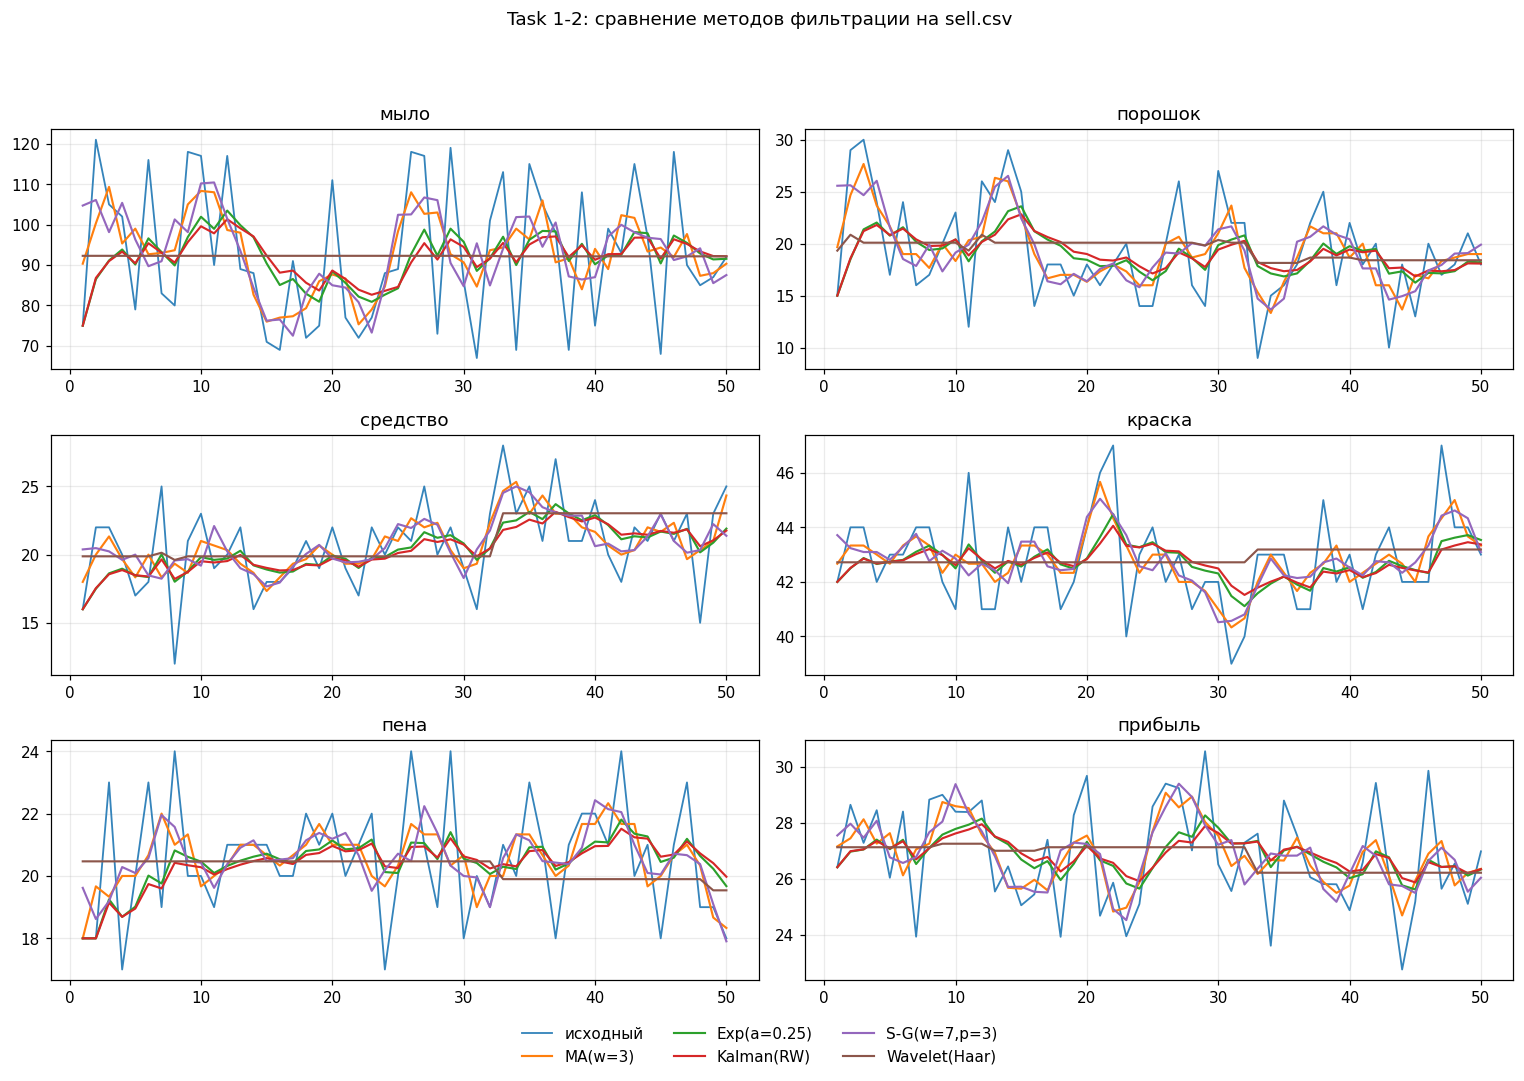

In [2]:
data = load_sell_csv_variant(SELL_CSV_PATH, VARIANT)
days = data.days
series = data.series

names = list(series.keys())
n = len(days)

ma_win = (max(3, int(round(n / 15))) | 1)
ma_win = min(ma_win, n if n % 2 == 1 else max(1, n - 1))
exp_alpha = 0.25
kalman = KalmanParams(q=1.0, r=25.0, p0=10.0)
sg_win = (max(7, int(round(n / 10))) | 1)
sg_win = min(sg_win, n if n % 2 == 1 else max(1, n - 1))
sg_poly = 3
if sg_win <= sg_poly:
    sg_poly = max(1, sg_win - 2)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.reshape(-1)

for ax, name in zip(axes, names, strict=False):
    x = series[name]
    ax.plot(days, x, label="исходный", linewidth=1.2, alpha=0.9)
    ax.plot(days, moving_average(x, ma_win), label=f"MA(w={ma_win})", linewidth=1.4)
    ax.plot(days, exponential_smoothing(x, exp_alpha), label=f"Exp(a={exp_alpha})", linewidth=1.4)
    ax.plot(days, kalman_filter_1d_random_walk(x, kalman), label="Kalman(RW)", linewidth=1.4)
    ax.plot(days, savitzky_golay(x, sg_win, sg_poly), label=f"S-G(w={sg_win},p={sg_poly})", linewidth=1.4)
    ax.plot(days, wavelet_denoise_haar(x, level=None), label="Wavelet(Haar)", linewidth=1.4)
    ax.set_title(name)
    ax.grid(True, alpha=0.25)

for ax in axes[len(names) :]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.01))
fig.suptitle("Task 1-2: сравнение методов фильтрации на sell.csv", y=0.98)
fig.tight_layout(rect=(0, 0.06, 1, 0.94))

plt.show()


## Task 3: Анализ данных (корреляции, ACF, FFT)

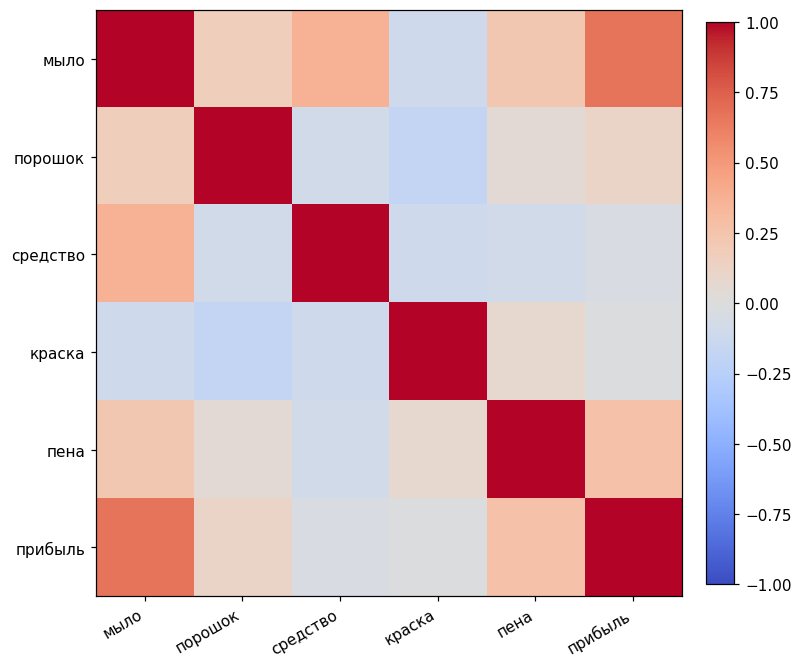

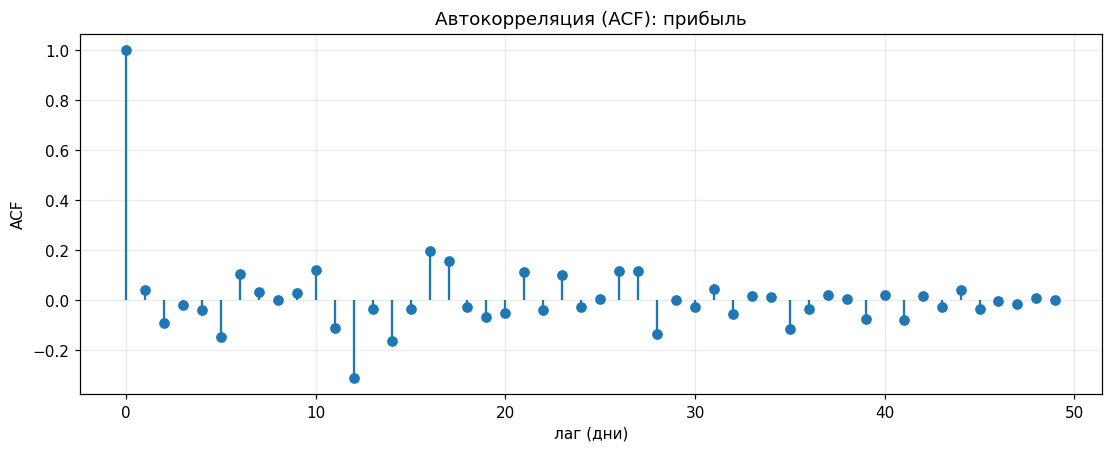

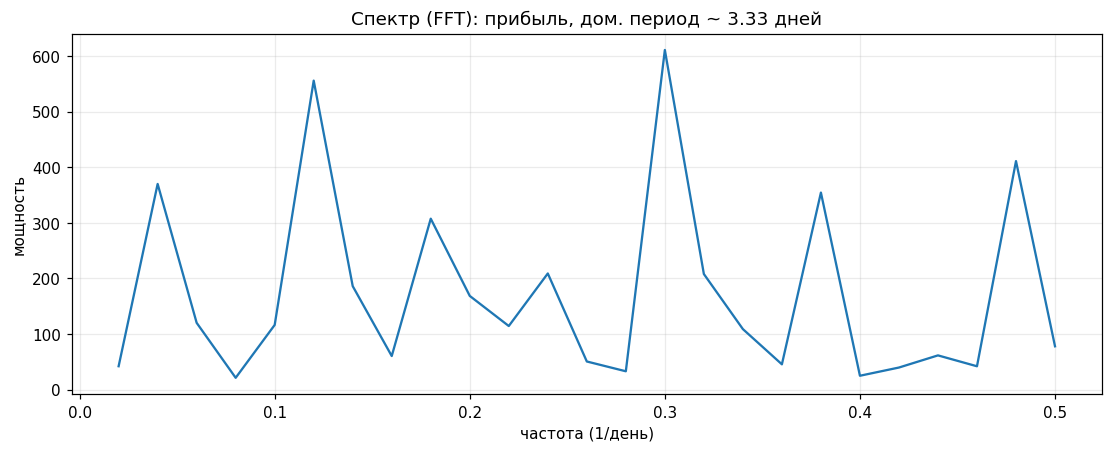

Вариант: 11
Длина ряда: 50 (дни 1..50)

Базовые метрики и периодичность (FFT)
- мыло: mean=92.980, std=17.506, min=67.000, max=121.000, trend_slope/step=-0.0410, dom_period~3.33
- порошок: mean=19.180, std=4.885, min=9.000, max=30.000, trend_slope/step=-0.0905, dom_period~12.50
- средство: mean=20.740, std=3.102, min=12.000, max=28.000, trend_slope/step=0.0703, dom_period~3.33
- краска: mean=42.800, std=1.702, min=39.000, max=47.000, trend_slope/step=-0.0030, dom_period~4.55
- пена: mean=20.540, std=1.843, min=17.000, max=24.000, trend_slope/step=0.0053, dom_period~2.94
- прибыль: mean=26.849, std=1.874, min=22.752, max=30.566, trend_slope/step=-0.0240, dom_period~3.33


In [3]:
keys, corr = correlation_matrix(series)
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
im = ax.imshow(corr, vmin=-1.0, vmax=1.0, cmap="coolwarm")
ax.set_xticks(range(len(keys)), keys, rotation=30, ha="right")
ax.set_yticks(range(len(keys)), keys)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

target_key = "прибыль"
x = series[target_key]

max_lag = min(60, len(x) - 1)
acf = autocorrelation(x, max_lag=max_lag)
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.stem(range(len(acf)), acf, basefmt=" ")
ax.set_title(f"Автокорреляция (ACF): {target_key}")
ax.set_xlabel("лаг (дни)")
ax.set_ylabel("ACF")
ax.grid(True, alpha=0.25)
plt.show()

period, freqs, power = dominant_period_via_fft(x, fs=1.0)
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.plot(freqs[1:], power[1:])
title = f"Спектр (FFT): {target_key}"
if period:
    title += f", дом. период ~ {period:.2f} дней"
ax.set_title(title)
ax.set_xlabel("частота (1/день)")
ax.set_ylabel("мощность")
ax.grid(True, alpha=0.25)
plt.show()

lines = []
lines.append(f"Вариант: {VARIANT}")
lines.append(f"Длина ряда: {len(days)} (дни {int(days.min())}..{int(days.max())})")
lines.append("")
lines.append("Базовые метрики и периодичность (FFT)")
for k, arr in series.items():
    st = series_stats(arr)
    p, _f, _pow = dominant_period_via_fft(arr, fs=1.0)
    if p:
        lines.append(
            f"- {k}: mean={st.mean:.3f}, std={st.std:.3f}, min={st.min:.3f}, max={st.max:.3f}, "
            f"trend_slope/step={st.trend_slope_per_step:.4f}, dom_period~{p:.2f}"
        )
    else:
        lines.append(
            f"- {k}: mean={st.mean:.3f}, std={st.std:.3f}, min={st.min:.3f}, max={st.max:.3f}, "
            f"trend_slope/step={st.trend_slope_per_step:.4f}, dom_period=NA"
        )

print("\n".join(lines))


## Task 4: `city_day.csv` как датасет с двумя "датчиками" (PM2.5 и PM10)

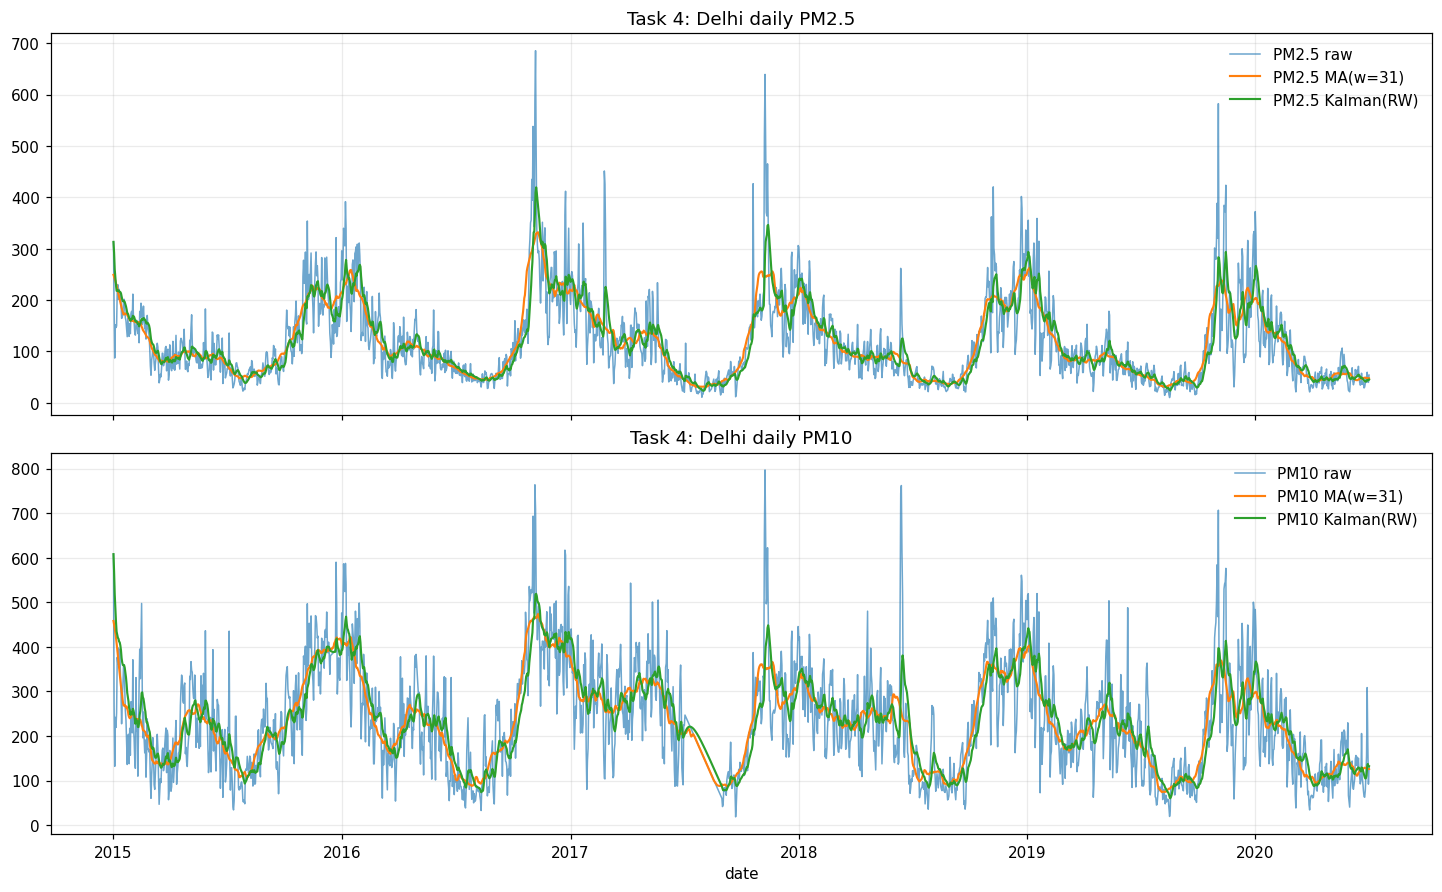

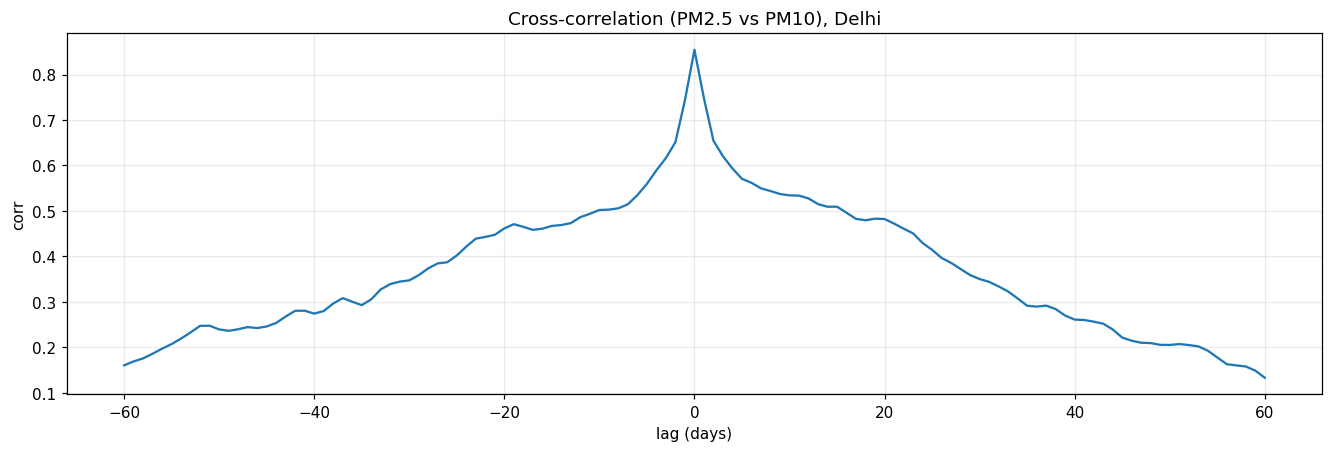

City: Delhi
Date range: 2015-01-01 .. 2020-07-01 (n=2009)
Sensors: PM2.5 and PM10

PM2.5: mean=117.10, std=82.92, min=10.24, max=685.36, trend_slope/day=-0.0160, dominant_period~334.83 days
PM10: mean=231.10, std=121.06, min=18.59, max=796.88, trend_slope/day=-0.0282, dominant_period~182.64 days

Pearson corr(PM2.5,PM10)=0.8546
Cross-correlation: best |corr|=0.8546 at lag=0 days (corr=0.8546).



In [4]:
pair = load_city_day_pair(CITY_DAY_PATH, city=CITY, a_col=CITY_A_COL, b_col=CITY_B_COL)
a = fill_nans_linear(pair.a)
b = fill_nans_linear(pair.b)

n = min(len(a), len(b))
win = min(31, n if n % 2 == 1 else max(1, n - 1))
a_ma = moving_average(a, win)
b_ma = moving_average(b, win)
a_k = kalman_filter_1d_random_walk(a, KalmanParams(q=1.0, r=50.0, p0=10.0))
b_k = kalman_filter_1d_random_walk(b, KalmanParams(q=1.0, r=80.0, p0=10.0))

fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True, sharex=True)
axes[0].plot(pair.dates, a, label=f"{pair.a_name} raw", linewidth=1.0, alpha=0.65)
axes[0].plot(pair.dates, a_ma, label=f"{pair.a_name} MA(w={win})", linewidth=1.4)
axes[0].plot(pair.dates, a_k, label=f"{pair.a_name} Kalman(RW)", linewidth=1.4)
axes[0].set_title(f"Task 4: {pair.city} daily {pair.a_name}")
axes[0].grid(True, alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(pair.dates, b, label=f"{pair.b_name} raw", linewidth=1.0, alpha=0.65)
axes[1].plot(pair.dates, b_ma, label=f"{pair.b_name} MA(w={win})", linewidth=1.4)
axes[1].plot(pair.dates, b_k, label=f"{pair.b_name} Kalman(RW)", linewidth=1.4)
axes[1].set_title(f"Task 4: {pair.city} daily {pair.b_name}")
axes[1].grid(True, alpha=0.25)
axes[1].legend(frameon=False)

axes[1].set_xlabel("date")
plt.show()

lags, cc = cross_correlation(a, b, max_lag=60)
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
ax.plot(lags, cc)
ax.set_title(f"Cross-correlation ({pair.a_name} vs {pair.b_name}), {pair.city}")
ax.set_xlabel("lag (days)")
ax.set_ylabel("corr")
ax.grid(True, alpha=0.25)

plt.show()

best_i = int(np.argmax(np.abs(cc)))
best_lag = int(lags[best_i])
best_corr = float(cc[best_i])
pearson = float(np.corrcoef(a, b)[0, 1])
a_period, *_ = dominant_period_via_fft(a, fs=1.0)
b_period, *_ = dominant_period_via_fft(b, fs=1.0)
a_st = series_stats(a)
b_st = series_stats(b)

text = (
    f"City: {pair.city}\n"
    f"Date range: {pair.dates[0].isoformat()} .. {pair.dates[-1].isoformat()} (n={len(pair.dates)})\n"
    f"Sensors: {pair.a_name} and {pair.b_name}\n\n"
    f"{pair.a_name}: mean={a_st.mean:.2f}, std={a_st.std:.2f}, min={a_st.min:.2f}, max={a_st.max:.2f}, "
    f"trend_slope/day={a_st.trend_slope_per_step:.4f}, dominant_period~{a_period:.2f} days\n"
    f"{pair.b_name}: mean={b_st.mean:.2f}, std={b_st.std:.2f}, min={b_st.min:.2f}, max={b_st.max:.2f}, "
    f"trend_slope/day={b_st.trend_slope_per_step:.4f}, dominant_period~{b_period:.2f} days\n\n"
    f"Pearson corr({pair.a_name},{pair.b_name})={pearson:.4f}\n"
    f"Cross-correlation: best |corr|={abs(best_corr):.4f} at lag={best_lag} days (corr={best_corr:.4f}).\n"
)
print(text)